# Analysis of the impact of diploidy

Is diploidy really useful for this project, and in which way does it help the evolution of my soft robot ? 

## Does the diversity exist and for what purpose ?

Allelic distance between the two haplotypes of a same genome, generation after generation, diploid only.

It has to stay > or big 0. 

The statistics are computed on the top_n best individuals of each generation, not on the whole


In [14]:
import os 
import json 
import dill 
import matplotlib.pyplot as plt
import numpy as np
import sys

from base_fns import get_local_file
file = get_local_file()

local_dir = os.path.dirname(os.path.dirname(file))
sys.path.append(local_dir)

from config import Config
from tools.distance import DistanceTool


def add_env_switch_lines(config, generations, label='env switch'):
    
    if 'switch' not in config:
        return
    switch = config['switch']
    max_gen = int(np.max(generations))
    for j, g in enumerate(range(switch, max_gen + 1, switch)):
        plt.axvline(x=g, color='grey', linestyle='--', alpha=0.65,
                    label=label if j == 0 else None)

## How to use

Please change the direction of the results you want to analyze, and `top_n`, the number of best
individuals the distances are averaged on : 
this is because the best are the more likely to have a switch in their genome 

In [15]:
# to change 
path = 'changingenv10'
number = 1
top_n = 5
# end of to change 

results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(number))
diploid_dir = os.path.join(results_dir, 'diploid')
json_diploid_dir = os.path.join(diploid_dir, 'json')
file = 'configs.json'
diploid_json_dir_file = os.path.join(json_diploid_dir, file)

with open(diploid_json_dir_file, 'r') as f : 
    diploid_data_config = json.load(f)

config = Config(diploid_data_config)
distance_tool = DistanceTool(config)

diploid_result = ''
for key, value in diploid_data_config.items():
    diploid_result += f'{key} : {value}\n'

print(diploid_result)

number_of_exp : 2
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.15
threshold_weight : 0.05
threshold_bias : 0.03
threshold_function : 0.03
threshold_dominance : 0.07
switch : 30
generations : 330
population : 128
number_of_winner : 1
number_in_tournament : 3
number_of_elites : 2
shape_of_cppn : [[11], [5], [3, 3], [1, 1]]
function_pool : ['gaussian', 'sin', 'tanh']
n_steps : [1000, 600]
number_of_reported_individuals : 40
cpus : 32
env_name : ['Pusher-v0', 'Walker-v0']



## The allelic distance

In [16]:
def allelic_distance(genome, distance_tool, config) :

    connections1, connections2 = genome.connections
    bias1, bias2 = genome.biases
    functions1, functions2 = genome.functions

    weight_distance = 0 
    bias_distance = 0
    act_functions_distance = 0 

    count_weight = 0 
    count_bias = 0 

    for (previous_node, node) in connections1.keys() :
        weight_distance += np.abs(connections1[(previous_node, node)] - connections2[(previous_node, node)])
        count_weight += 1

    for node in bias1.keys() :
        bias_distance += np.abs(bias1[node] - bias2[node])
        act_functions_distance += 0 if distance_tool._same_activation(functions1[node], functions2[node]) else 1
        count_bias += 1

    number_of_nodes = count_bias

    normalized_weight_distance = weight_distance / (count_weight * 2 * config.range_weight)
    normalized_bias_distance = bias_distance / (count_bias * 2 * config.range_bias)
    normalized_act_functions_distance = act_functions_distance / number_of_nodes

    return normalized_act_functions_distance, normalized_weight_distance, normalized_bias_distance

## Study with graph

id_1 : 330 generations, 5.0 individuals kept on average, minimum 5


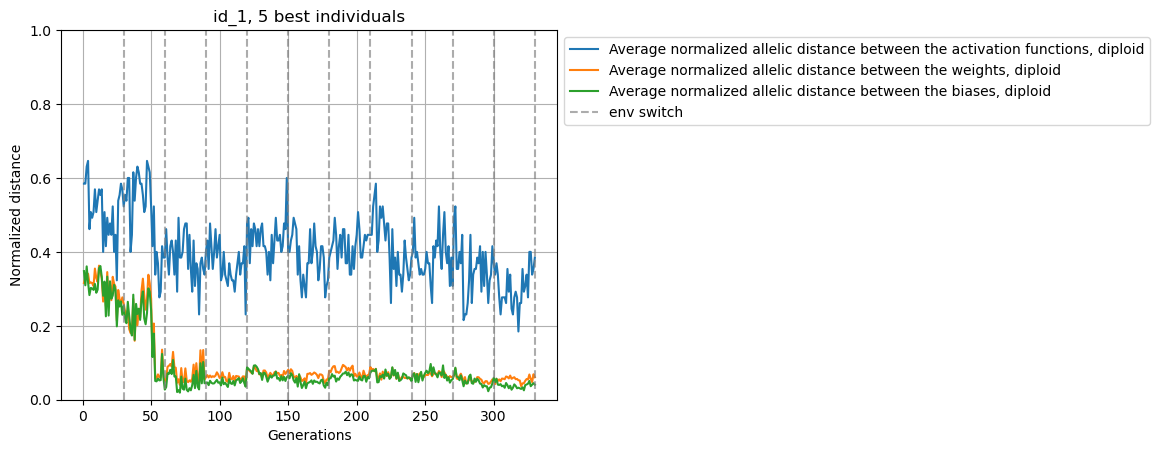

id_2 : 330 generations, 5.0 individuals kept on average, minimum 5


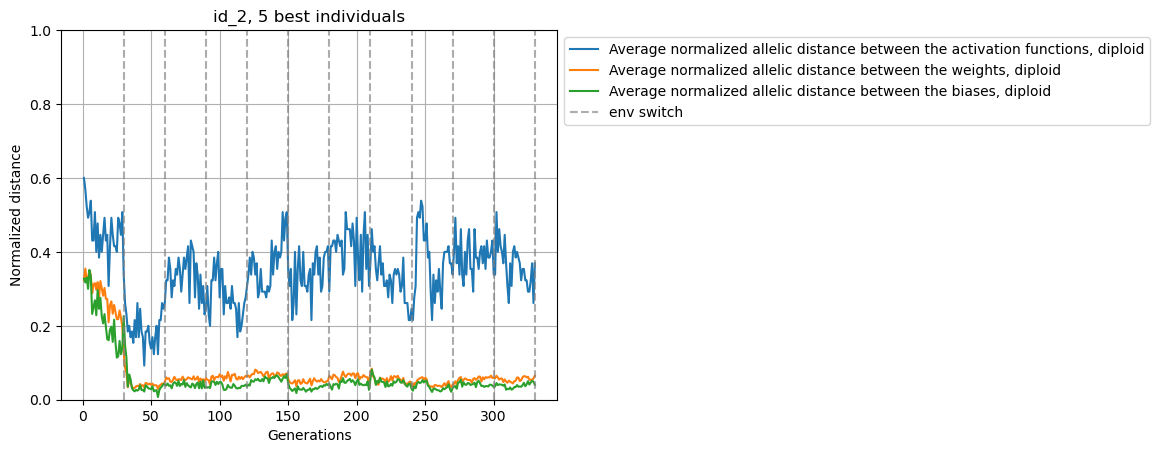

In [17]:
general_normalized_activation_function_distance_diploid = []
general_normalized_weight_distance_diploid = []
general_normalized_bias_distance_diploid = []
general_numbers_of_individuals_diploid = []


for k in range(diploid_data_config['number_of_config']) :
    general_normalized_activation_function_distance_diploid_sigma = []
    general_normalized_weight_distance_diploid_sigma = []
    general_normalized_bias_distance_diploid_sigma = []
    general_numbers_of_individuals_diploid_sigma = []
    for i in range(diploid_data_config['number_of_exp']) :
        id_exp = number + k * diploid_data_config['number_of_exp'] + i
        results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(id_exp))
        diploid_dir = os.path.join(results_dir, 'diploid')

        generation = 1
        pkl_dir = os.path.join(diploid_dir, 'pkl')
        generations = []
        average_list_normalized_activation_function_distance = []
        average_list_normalized_weight_distance = []
        average_list_normalized_bias_distance = []
        numbers_of_individuals = []

        while True :

            fitness_file_dir = os.path.join(pkl_dir, '{}_fitness_registry.pkl'.format(generation))
            genome_file_dir = os.path.join(pkl_dir, '{}_genome_registry.pkl'.format(generation))

            if not os.path.exists(fitness_file_dir) or not os.path.exists(genome_file_dir) :
                break

            with open(fitness_file_dir, 'rb') as f :
                loaded_file_fitness = dill.load(f)

            with open(genome_file_dir, 'rb') as f :
                loaded_file_genome = dill.load(f)

            # only the valid individuals are saved, but the sentinel is filtered anyway
            list_of_keys = [key for key in loaded_file_fitness.keys()
                            if key in loaded_file_genome and loaded_file_fitness[key].fitness > -1000]
            list_of_keys.sort(key = lambda key : loaded_file_fitness[key].fitness, reverse = True)
            list_of_keys = list_of_keys[:top_n]

            if not list_of_keys :
                generation += 1
                continue

            normalized_act_function_distances = []
            normalized_weight_distances = []
            normalized_bias_distances = []

            for key in list_of_keys :
                genome = loaded_file_genome[key]
                normalized_act_function_distance, normalized_weight_distance, normalized_bias_distance = allelic_distance(genome, distance_tool, config)

                normalized_act_function_distances.append(normalized_act_function_distance)
                normalized_weight_distances.append(normalized_weight_distance)
                normalized_bias_distances.append(normalized_bias_distance)

            average_normalized_act_function_distance = np.mean(np.array(normalized_act_function_distances))
            average_normalized_weight_distance = np.mean(np.array(normalized_weight_distances))
            average_normalized_bias_distance = np.mean(np.array(normalized_bias_distances))

            average_list_normalized_activation_function_distance.append(average_normalized_act_function_distance)
            average_list_normalized_weight_distance.append(average_normalized_weight_distance)
            average_list_normalized_bias_distance.append(average_normalized_bias_distance)
            numbers_of_individuals.append(len(list_of_keys))

            generations.append(generation)
            generation += 1

        print('id_{} : {} generations, {:.1f} individuals kept on average, minimum {}'.format(
            id_exp, len(generations), np.mean(np.array(numbers_of_individuals)), np.min(np.array(numbers_of_individuals))))

        plt.figure()
        plt.title('id_{}, {} best individuals'.format(id_exp, top_n))
        plt.plot(generations, average_list_normalized_activation_function_distance, label = 'Average normalized allelic distance between the activation functions, diploid')
        plt.plot(generations, average_list_normalized_weight_distance, label = 'Average normalized allelic distance between the weights, diploid')
        plt.plot(generations, average_list_normalized_bias_distance, label = 'Average normalized allelic distance between the biases, diploid')
        plt.xlabel('Generations')
        plt.ylabel('Normalized distance')
        plt.ylim(0, 1)
        plt.grid(True, which = 'both')
        add_env_switch_lines(diploid_data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        general_normalized_activation_function_distance_diploid_sigma.append(average_list_normalized_activation_function_distance)
        general_normalized_weight_distance_diploid_sigma.append(average_list_normalized_weight_distance)
        general_normalized_bias_distance_diploid_sigma.append(average_list_normalized_bias_distance)
        general_numbers_of_individuals_diploid_sigma.append(numbers_of_individuals)

    general_normalized_activation_function_distance_diploid.append(general_normalized_activation_function_distance_diploid_sigma)
    general_normalized_weight_distance_diploid.append(general_normalized_weight_distance_diploid_sigma)
    general_normalized_bias_distance_diploid.append(general_normalized_bias_distance_diploid_sigma)
    general_numbers_of_individuals_diploid.append(general_numbers_of_individuals_diploid_sigma)

## Mean over every run

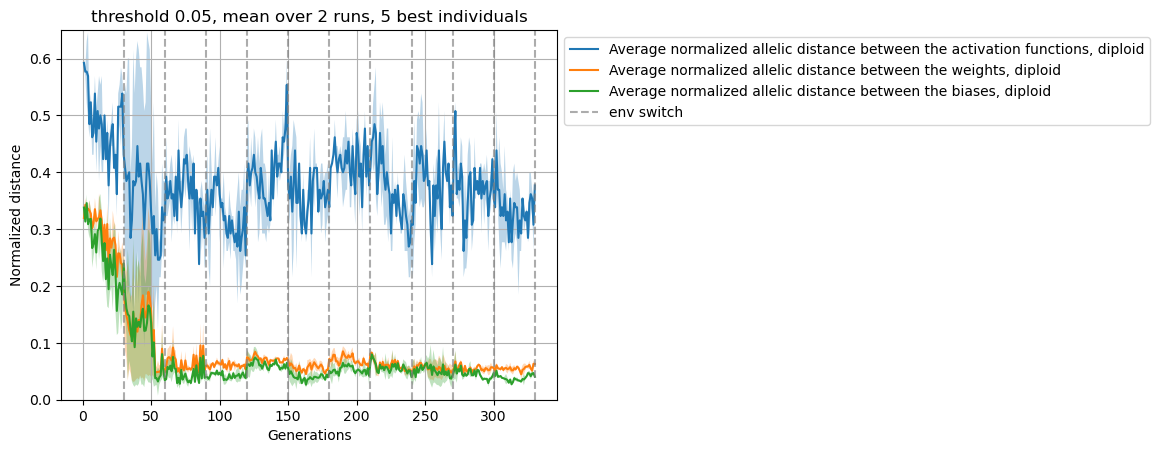

In [18]:
for k in range(diploid_data_config['number_of_config']) :
    threshold = diploid_data_config['threshold_weight'] + k * diploid_data_config['threshold_var']

    length = min([len(distances) for distances in general_normalized_weight_distance_diploid[k]])
    truncated_generations = generations[:length]

    activation_functions = np.array([distances[:length] for distances in general_normalized_activation_function_distance_diploid[k]])
    weights = np.array([distances[:length] for distances in general_normalized_weight_distance_diploid[k]])
    biases = np.array([distances[:length] for distances in general_normalized_bias_distance_diploid[k]])

    mean_normalized_activation_function_distance_diploid = np.mean(activation_functions, axis = 0)
    mean_normalized_weight_distance_diploid = np.mean(weights, axis = 0)
    mean_normalized_bias_distance_diploid = np.mean(biases, axis = 0)

    std_normalized_activation_function_distance_diploid = np.std(activation_functions, axis = 0)
    std_normalized_weight_distance_diploid = np.std(weights, axis = 0)
    std_normalized_bias_distance_diploid = np.std(biases, axis = 0)

    plt.figure()
    plt.title('threshold {:.2f}, mean over {} runs, {} best individuals'.format(threshold, len(weights), top_n))
    plt.plot(truncated_generations, mean_normalized_activation_function_distance_diploid, label = 'Average normalized allelic distance between the activation functions, diploid')
    plt.fill_between(truncated_generations, mean_normalized_activation_function_distance_diploid - std_normalized_activation_function_distance_diploid, mean_normalized_activation_function_distance_diploid + std_normalized_activation_function_distance_diploid, alpha = 0.3)
    plt.plot(truncated_generations, mean_normalized_weight_distance_diploid, label = 'Average normalized allelic distance between the weights, diploid')
    plt.fill_between(truncated_generations, mean_normalized_weight_distance_diploid - std_normalized_weight_distance_diploid, mean_normalized_weight_distance_diploid + std_normalized_weight_distance_diploid, alpha = 0.3)
    plt.plot(truncated_generations, mean_normalized_bias_distance_diploid, label = 'Average normalized allelic distance between the biases, diploid')
    plt.fill_between(truncated_generations, mean_normalized_bias_distance_diploid - std_normalized_bias_distance_diploid, mean_normalized_bias_distance_diploid + std_normalized_bias_distance_diploid, alpha = 0.3)
    plt.xlabel('Generations')
    plt.ylabel('Normalized distance')
    plt.ylim(0, 0.65)
    plt.grid(True, which = 'both')
    add_env_switch_lines(diploid_data_config, truncated_generations)
    plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
    plt.show()

## Sanity check

In [19]:
shape_of_cppn = diploid_data_config['shape_of_cppn']
number_of_nodes = sum([sum(layer) for layer in shape_of_cppn[1:]])
number_of_outputs = sum(shape_of_cppn[-1])

expected_act_functions_distance = (number_of_nodes - number_of_outputs) / number_of_nodes * (1 - 1 / len(diploid_data_config['function_pool']))
print('{} nodes carrying a gene, {} of them frozen to the identity (the cppn outputs)'.format(number_of_nodes, number_of_outputs))
print('generation 1, expected : activation functions {:.2f}, weights 0.33, biases 0.33'.format(expected_act_functions_distance))
print()

for k in range(diploid_data_config['number_of_config']) :
    for i in range(len(general_normalized_weight_distance_diploid[k])) :
        print('config {} run {} : activation functions {:.3f}, weights {:.3f}, biases {:.3f}'.format(
            k, i,
            general_normalized_activation_function_distance_diploid[k][i][0],
            general_normalized_weight_distance_diploid[k][i][0],
            general_normalized_bias_distance_diploid[k][i][0]))

print()
print('over every run and generation :')
print('  activation functions [{:.3f}, {:.3f}]'.format(np.min(activation_functions), np.max(activation_functions)))
print('  weights              [{:.3f}, {:.3f}]'.format(np.min(weights), np.max(weights)))
print('  biases               [{:.3f}, {:.3f}]'.format(np.min(biases), np.max(biases)))

13 nodes carrying a gene, 2 of them frozen to the identity (the cppn outputs)
generation 1, expected : activation functions 0.56, weights 0.33, biases 0.33

config 0 run 0 : activation functions 0.585, weights 0.316, biases 0.348
config 0 run 1 : activation functions 0.600, weights 0.323, biases 0.328

over every run and generation :
  activation functions [0.092, 0.646]
  weights              [0.029, 0.363]
  biases               [0.007, 0.362]
